# K-Nearest Neighbors Classification
Visualizing decision boundaries and neighbor connections using our custom `MyKNNClassifier`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn import datasets
from sklearn.model_selection import train_test_split
from knn_classifier import MyKNNClassifier

In [2]:
# Load Iris Data (2 features for visualization)
iris = datasets.load_iris()
X = iris.data[:, :2] # Sepal Length, Sepal Width
y = iris.target
cmap = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

## 1. Decision Boundary Visualization
We calculate the prediction for every point in a grid to show the 'territory' of each class.

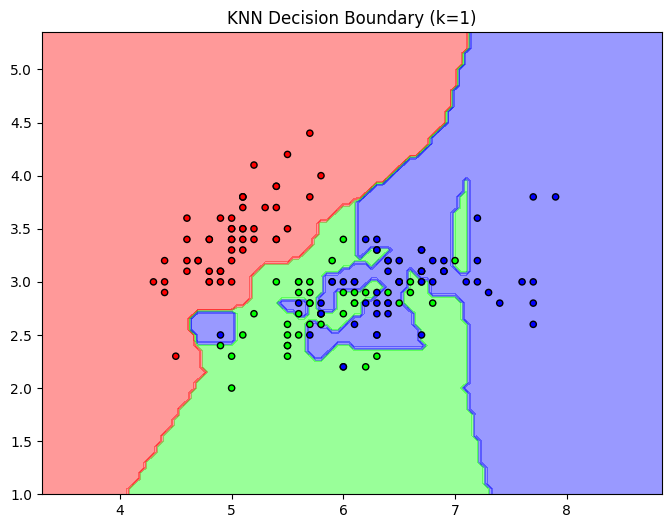

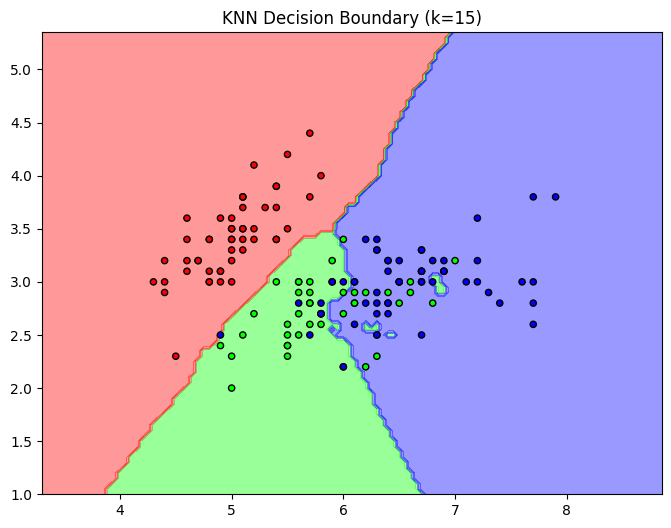

In [3]:
def plot_boundary(k):
    clf = MyKNNClassifier(k=k)
    clf.fit(X_train, y_train)
    
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap=cmap)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k', cmap=cmap)
    plt.title(f"KNN Decision Boundary (k={k})")
    plt.show()

plot_boundary(k=1)
plot_boundary(k=15)

## 2. Neighbor Connections (The 'Spider' Plot)
Visualizing exactly which training points are 'voting' for a specific test query.

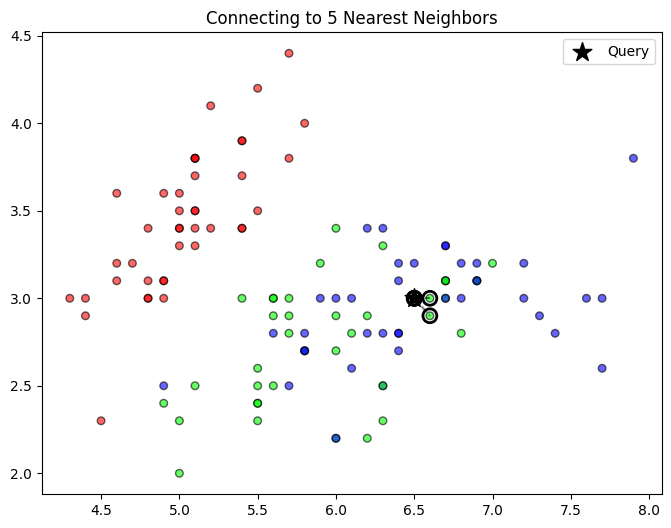

In [4]:
def plot_neighbors(query_point, k=5):
    clf = MyKNNClassifier(k=k)
    clf.fit(X_train, y_train)
    
    # Manual distance calc for plotting
    distances = [np.linalg.norm(query_point - x) for x in X_train]
    k_indices = np.argsort(distances)[:k]
    
    plt.figure(figsize=(8, 6))
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cmap, s=30, edgecolor='k', alpha=0.6)
    plt.scatter(query_point[0], query_point[1], c='black', marker='*', s=200, label='Query')
    
    for i in k_indices:
        neighbor = X_train[i]
        plt.plot([query_point[0], neighbor[0]], [query_point[1], neighbor[1]], 'k--', alpha=0.5)
        plt.scatter(neighbor[0], neighbor[1], s=100, facecolors='none', edgecolors='k', linewidth=2)
        
    plt.title(f"Connecting to {k} Nearest Neighbors")
    plt.legend()
    plt.show()

plot_neighbors(np.array([6.5, 3.0]), k=5)